In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

In [5]:
data = pd.read_csv('indian_liver_patient - indian_liver_patient.csv')

In [6]:
data


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [7]:
data.columns = data.columns.str.lower().str.replace('_','')

In [8]:
data

,age,gender,totalbilirubin,directbilirubin,alkalinephosphotase,alamineaminotransferase,aspartateaminotransferase,totalprotiens,albumin,albuminandglobulinratio,dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        583 non-null    int64  
 1   gender                     583 non-null    object 
 2   totalbilirubin             583 non-null    float64
 3   directbilirubin            583 non-null    float64
 4   alkalinephosphotase        583 non-null    int64  
 5   alamineaminotransferase    583 non-null    int64  
 6   aspartateaminotransferase  583 non-null    int64  
 7   totalprotiens              583 non-null    float64
 8   albumin                    583 non-null    float64
 9   albuminandglobulinratio    579 non-null    float64
 10  dataset                    583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [10]:
data['albuminandglobulinratio'].unique()

array([0.9 , 0.74, 0.89, 1.  , 0.4 , 1.3 , 1.1 , 1.2 , 0.8 , 0.6 , 0.87,
       0.7 , 0.92, 0.55, 0.5 , 1.85, 0.95, 1.4 , 1.18, 0.61, 1.34, 1.39,
       1.6 , 1.58, 1.25, 0.78, 0.76, 1.55, 0.71, 0.62, 0.67, 0.75, 1.16,
       1.5 , 1.66, 0.96, 1.38, 0.52, 0.47, 0.93, 0.48, 0.58, 0.69, 1.27,
       1.12, 1.06, 0.53, 1.03, 0.68,  nan, 1.9 , 1.7 , 1.8 , 0.3 , 0.97,
       0.35, 1.51, 0.64, 0.45, 1.36, 0.88, 1.09, 1.11, 1.72, 2.8 , 0.46,
       0.39, 1.02, 2.5 , 0.37])

In [11]:
data['albuminandglobulinratio'].isna().sum()

np.int64(4)

In [12]:
mean_val = round(data['albuminandglobulinratio'].mean(),2)

In [13]:
data['albuminandglobulinratio'] = data['albuminandglobulinratio'].fillna(mean_val)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        583 non-null    int64  
 1   gender                     583 non-null    object 
 2   totalbilirubin             583 non-null    float64
 3   directbilirubin            583 non-null    float64
 4   alkalinephosphotase        583 non-null    int64  
 5   alamineaminotransferase    583 non-null    int64  
 6   aspartateaminotransferase  583 non-null    int64  
 7   totalprotiens              583 non-null    float64
 8   albumin                    583 non-null    float64
 9   albuminandglobulinratio    583 non-null    float64
 10  dataset                    583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [15]:
data['albuminandglobulinratio'].unique()

array([0.9 , 0.74, 0.89, 1.  , 0.4 , 1.3 , 1.1 , 1.2 , 0.8 , 0.6 , 0.87,
       0.7 , 0.92, 0.55, 0.5 , 1.85, 0.95, 1.4 , 1.18, 0.61, 1.34, 1.39,
       1.6 , 1.58, 1.25, 0.78, 0.76, 1.55, 0.71, 0.62, 0.67, 0.75, 1.16,
       1.5 , 1.66, 0.96, 1.38, 0.52, 0.47, 0.93, 0.48, 0.58, 0.69, 1.27,
       1.12, 1.06, 0.53, 1.03, 0.68, 1.9 , 1.7 , 1.8 , 0.3 , 0.97, 0.35,
       1.51, 0.64, 0.45, 1.36, 0.88, 1.09, 1.11, 1.72, 2.8 , 0.46, 0.39,
       1.02, 2.5 , 0.37])

In [16]:
data['gender']=data['gender'].map({'Female':0, 'Male':1 })

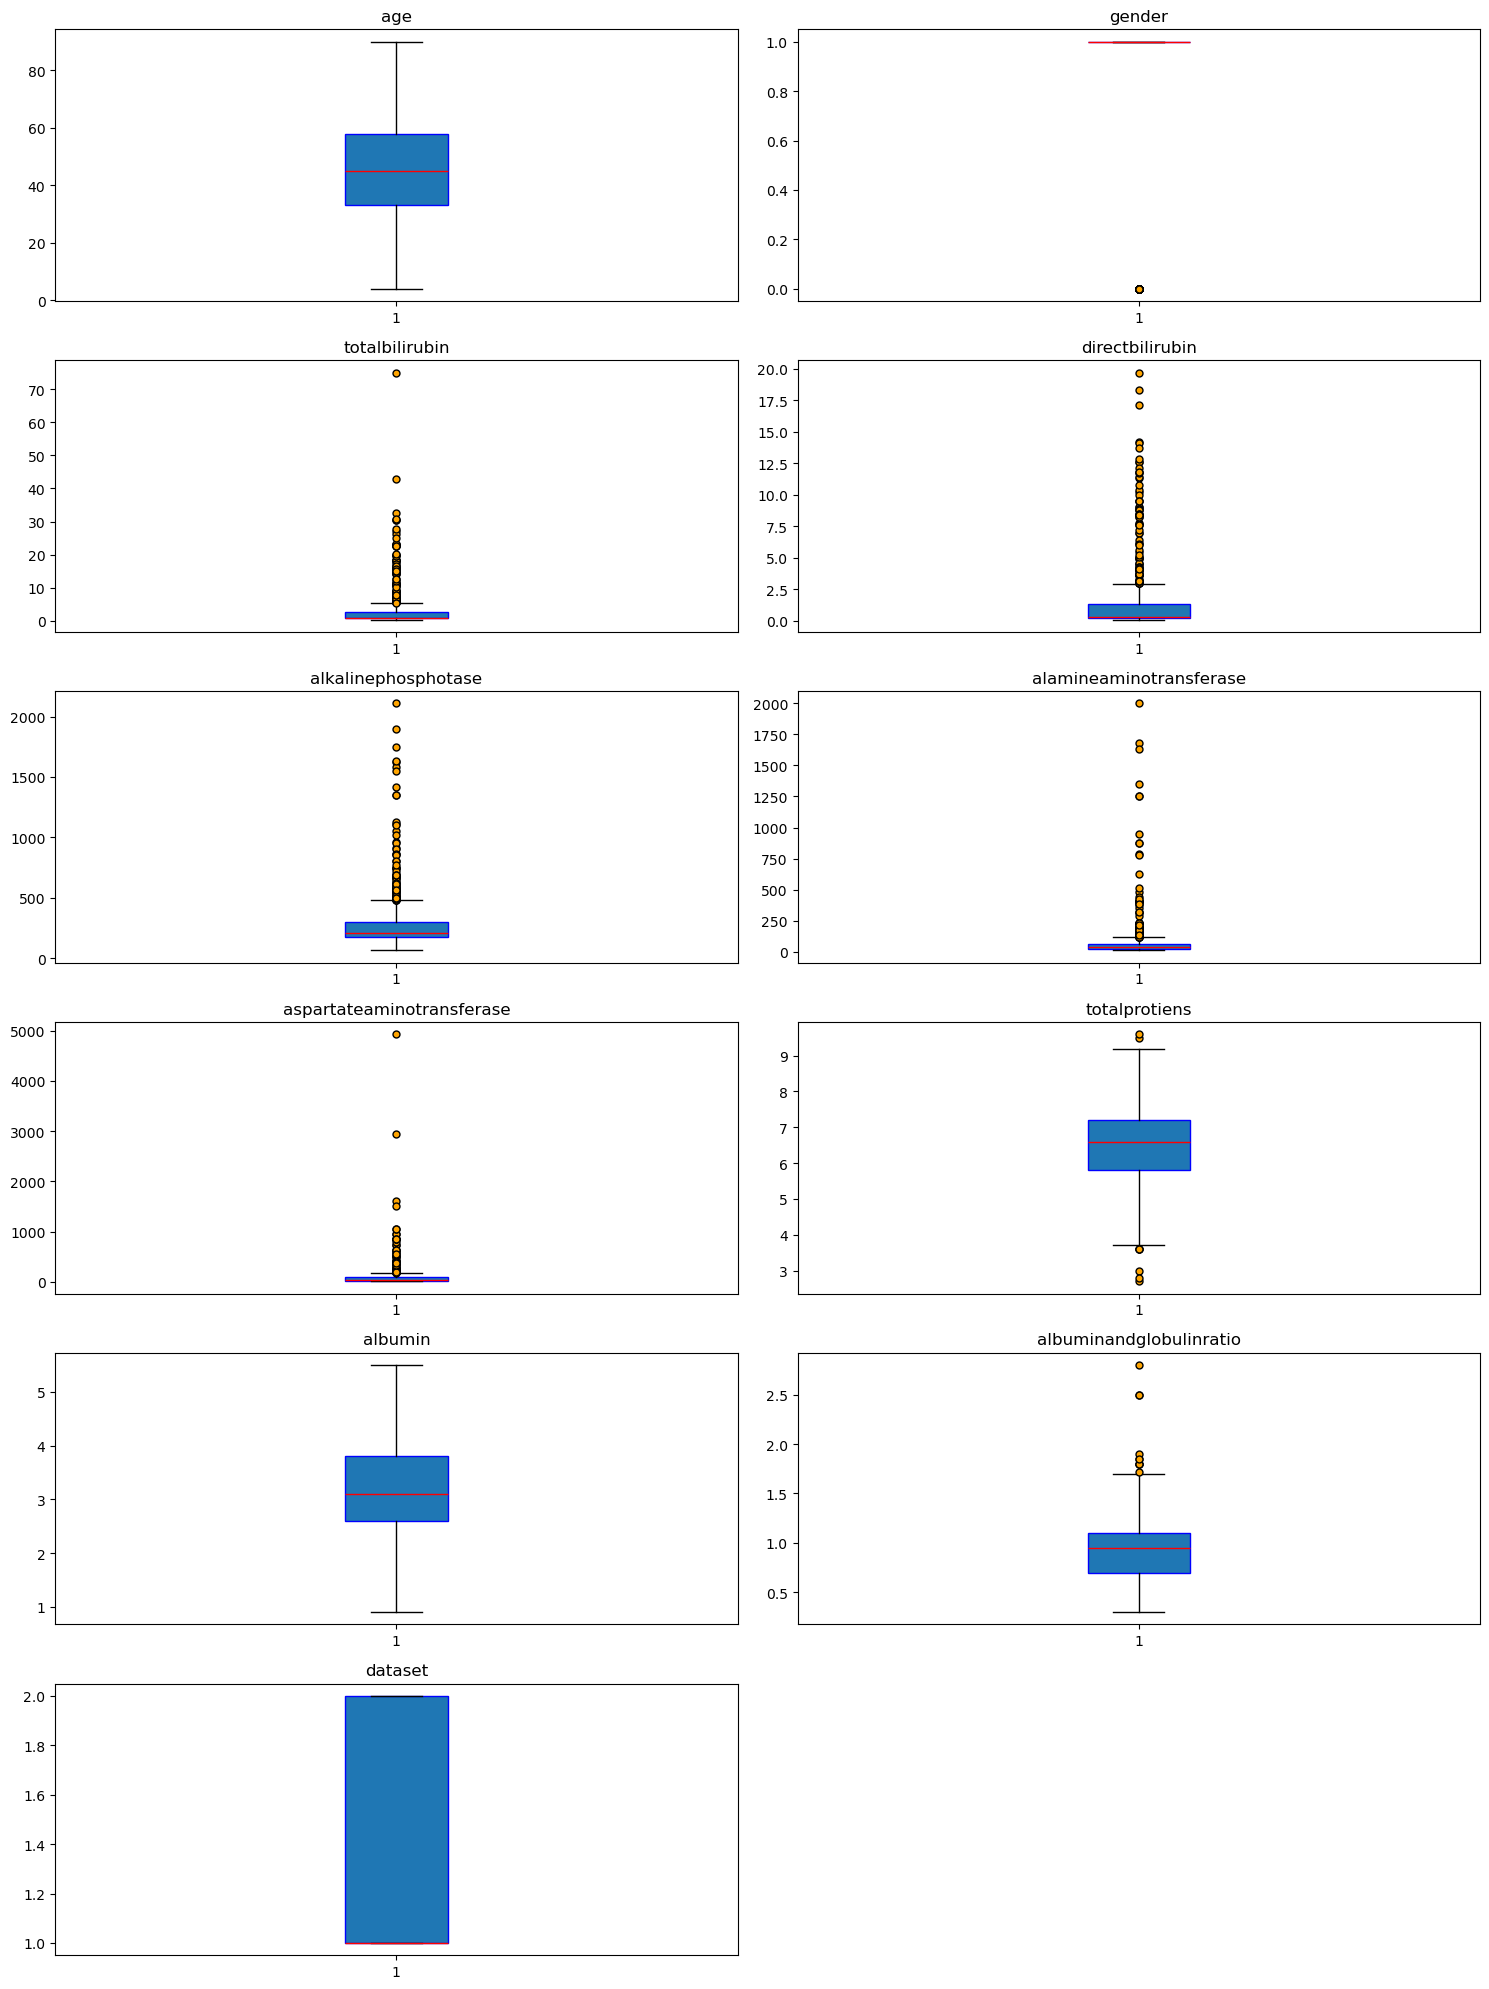

In [17]:
out_col =['age', 'gender', 'totalbilirubin', 'directbilirubin',
'alkalinephosphotase', 'alamineaminotransferase', 'aspartateaminotransferase', 'totalprotiens', 'albumin','albuminandglobulinratio', 'dataset']
plot=2
no_col=len(out_col)
plotting=(plot+no_col-1)//plot
plt.figure(figsize =(15, 20))
for i, col in enumerate(out_col, 1 ):
    plt.subplot(plotting,plot,i)
    plt.boxplot(data[col], patch_artist=True,
               boxprops=dict(color='blue'),
               whiskerprops=dict(color='black'),
               medianprops=dict(color='red'),
               capprops=dict(color='black'),
               flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))
    plt.title(col)
plt.tight_layout()
plt.show()
    

In [18]:
colu =['gender', 'totalbilirubin', 'directbilirubin', 'alkalinephosphotase', 'alamineaminotransferase', 'alamineaminotransferase', 'aspartateaminotransferase', 'totalprotiens', 'albuminandglobulinratio']
def out_columns(col, data):
    Q1 = data[col].quantile(0.25)
    Q2 = data[col].quantile(0.75)
    IQR = Q2 -Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q2 + 1.5*IQR
    data[col]=data[col].clip(lower = lower_bound, upper=upper_bound)
    return data
for i in colu:
    if i in data.columns:
        print(f"capping outLier :{i}")
        col = out_columns(i, data)
    else:
        print(f"Features {i} not found in Data Frame")

capping outLier :gender
capping outLier :totalbilirubin
capping outLier :directbilirubin
capping outLier :alkalinephosphotase
capping outLier :alamineaminotransferase
capping outLier :alamineaminotransferase
capping outLier :aspartateaminotransferase
capping outLier :totalprotiens
capping outLier :albuminandglobulinratio


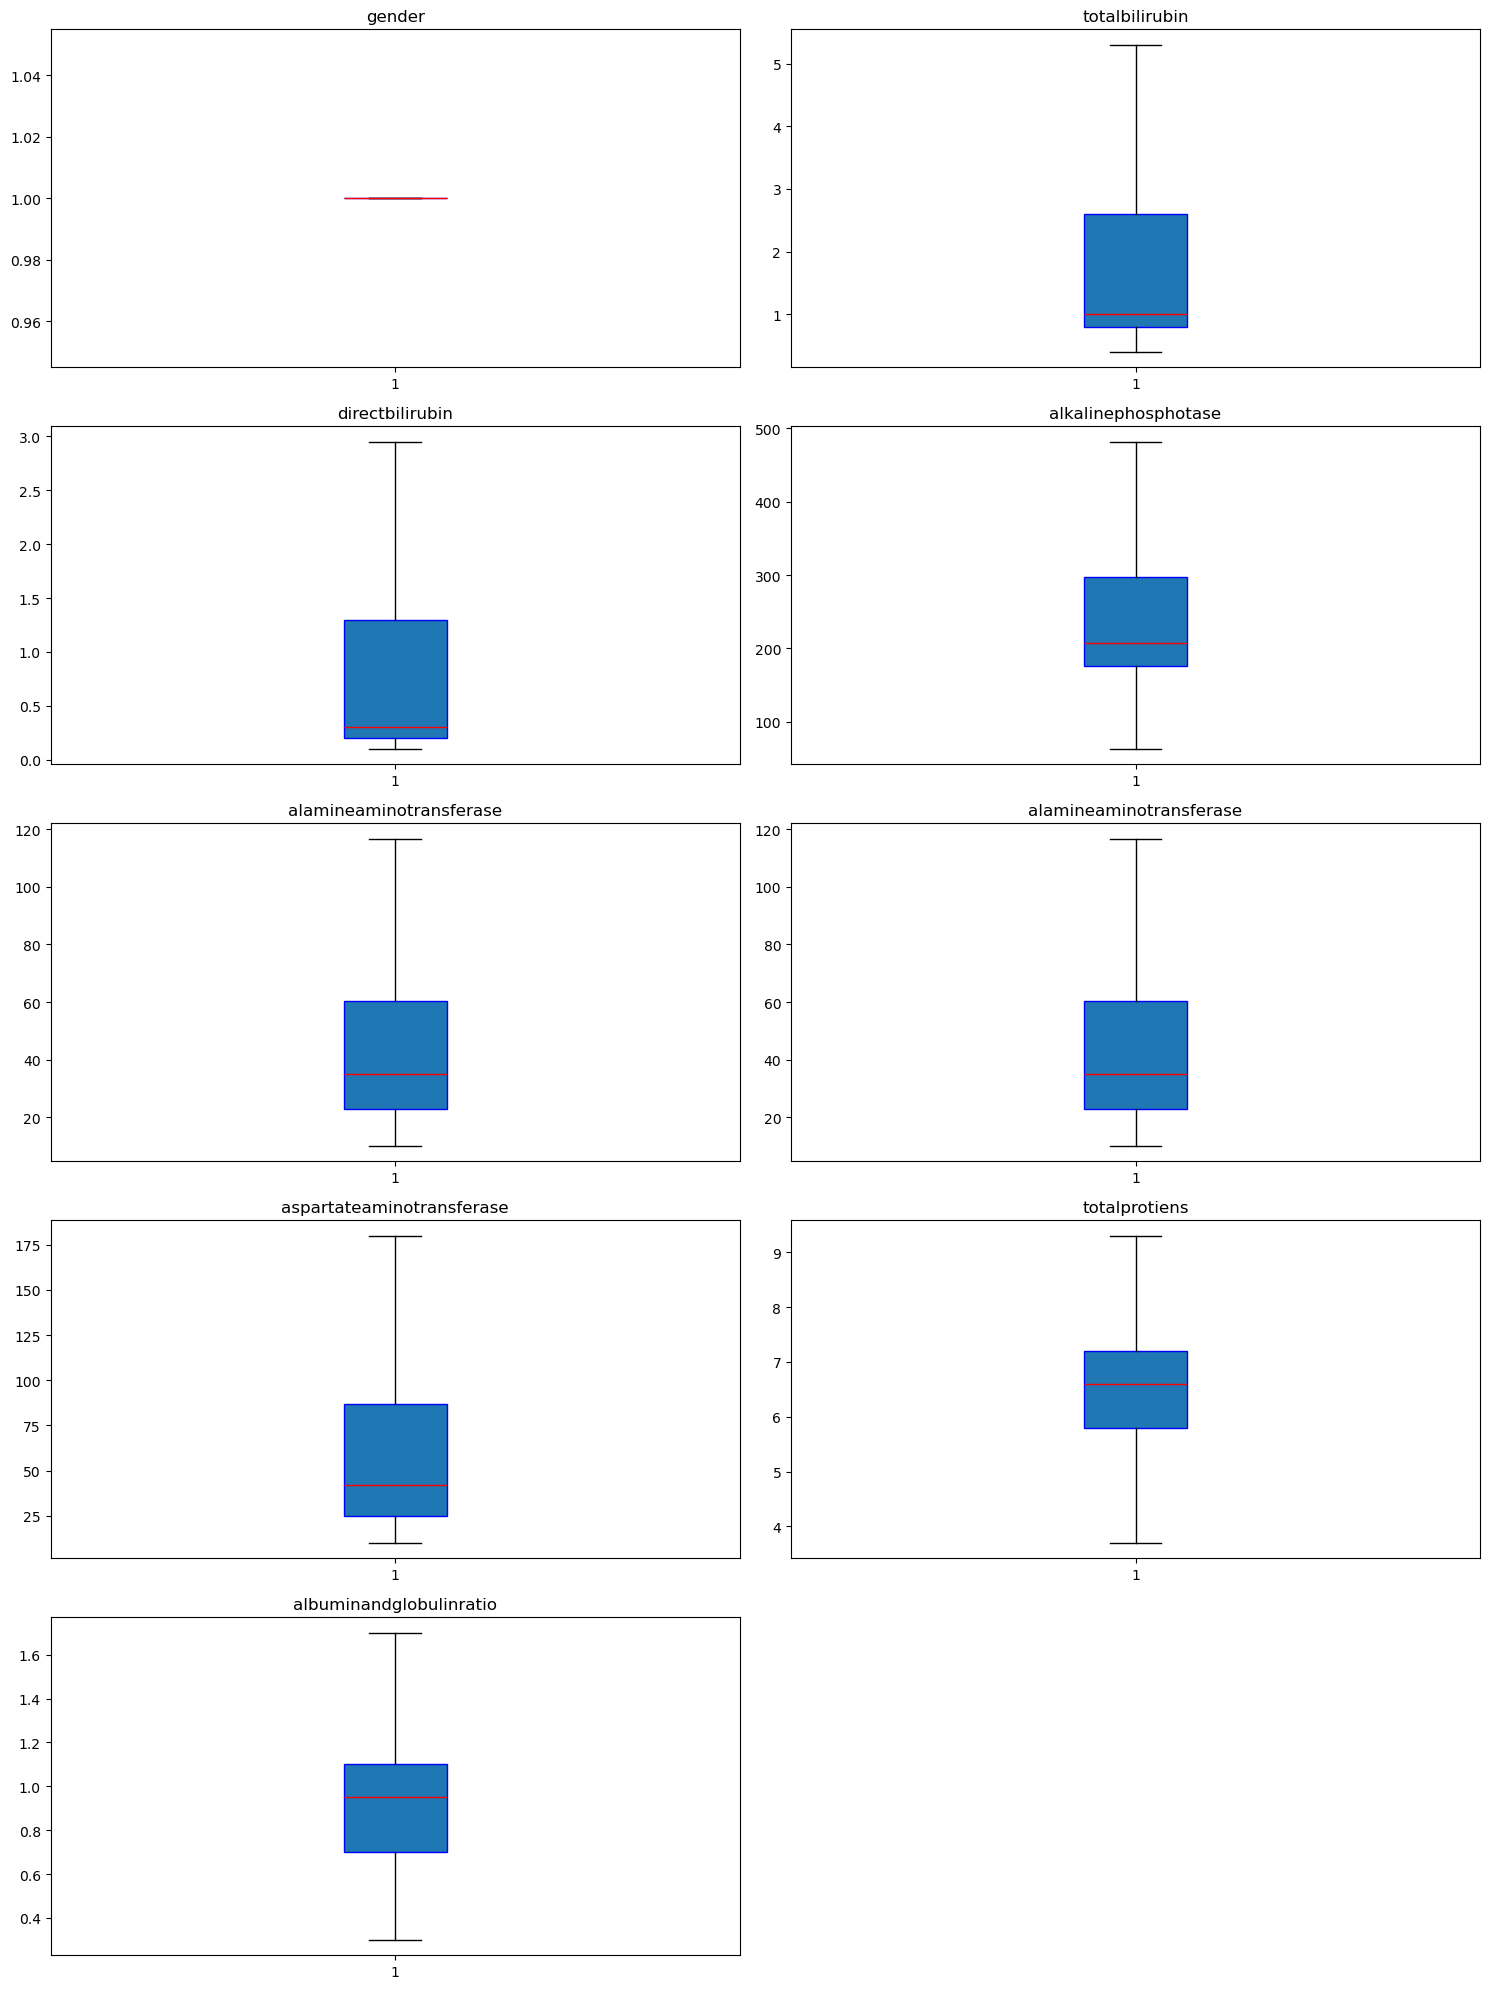

In [19]:
plot=2
no_col=len(colu)
plotting=(plot+no_col-1)//plot
plt.figure(figsize =(15, 20))
for i, col in enumerate(colu, 1 ):
    plt.subplot(plotting,plot,i)
    plt.boxplot(data[col], patch_artist=True,
               boxprops=dict(color='blue'),
               whiskerprops=dict(color='black'),
               medianprops=dict(color='red'),
               capprops=dict(color='black'),
               flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))
    plt.title(col)
plt.tight_layout()
plt.show()

<Axes: >

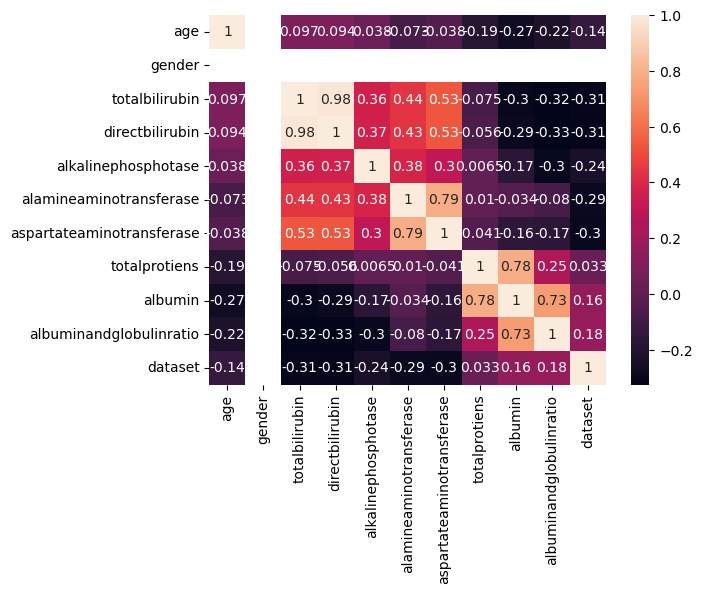

In [20]:
sns.heatmap(data.corr(), annot=True)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        583 non-null    int64  
 1   gender                     583 non-null    int64  
 2   totalbilirubin             583 non-null    float64
 3   directbilirubin            583 non-null    float64
 4   alkalinephosphotase        583 non-null    float64
 5   alamineaminotransferase    583 non-null    float64
 6   aspartateaminotransferase  583 non-null    int64  
 7   totalprotiens              583 non-null    float64
 8   albumin                    583 non-null    float64
 9   albuminandglobulinratio    583 non-null    float64
 10  dataset                    583 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 50.2 KB


In [22]:
SC = StandardScaler()

In [23]:
columns =['age','totalbilirubin', 'directbilirubin',
'alkalinephosphotase', 'alamineaminotransferase', 'aspartateaminotransferase', 'totalprotiens', 'albumin','albuminandglobulinratio']
data[columns]=SC.fit_transform(data[columns])

In [24]:
data

,age,gender,totalbilirubin,directbilirubin,alkalinephosphotase,alamineaminotransferase,aspartateaminotransferase,totalprotiens,albumin,albuminandglobulinratio,dataset
0,1.252098,1,-0.739010,-0.784798,-0.587479,-0.959220,-0.873527,0.292937,0.198969,-0.138630,1
1,1.066637,1,2.044134,2.083933,2.107251,0.484427,0.655913,0.948712,0.073157,-0.679017,1
2,1.066637,1,2.044134,2.083933,2.107251,0.364123,0.059058,0.480302,0.198969,-0.172405,1
3,0.819356,1,-0.557501,-0.482827,-0.633191,-1.019372,-0.836224,0.292937,0.324781,0.199111,1
4,1.684839,1,1.197090,1.127689,-0.514340,-0.628384,-0.108807,0.761348,-0.933340,-1.827338,1
...,...,...,...,...,...,...,...,...,...,...,...
578,0.942997,1,-0.860016,-0.784798,2.107251,-0.838916,-0.575100,-0.550202,-1.939837,-1.928661,2
579,-0.293407,1,-0.799513,-0.784798,-1.401155,-0.387776,-0.631055,-0.456520,0.073157,0.536853,1
580,0.448435,1,-0.678507,-0.684141,-0.057219,0.003211,-0.295324,-0.081791,0.073157,0.199111,1
581,-0.849789,1,-0.375991,-0.382169,-0.614907,-0.568232,-0.612403,0.292937,0.324781,0.199111,1


In [25]:
X = data.drop(columns ='dataset', axis=1)
Y = data['dataset']

In [26]:
X

,age,gender,totalbilirubin,directbilirubin,alkalinephosphotase,alamineaminotransferase,aspartateaminotransferase,totalprotiens,albumin,albuminandglobulinratio
0,1.252098,1,-0.739010,-0.784798,-0.587479,-0.959220,-0.873527,0.292937,0.198969,-0.138630
1,1.066637,1,2.044134,2.083933,2.107251,0.484427,0.655913,0.948712,0.073157,-0.679017
2,1.066637,1,2.044134,2.083933,2.107251,0.364123,0.059058,0.480302,0.198969,-0.172405
3,0.819356,1,-0.557501,-0.482827,-0.633191,-1.019372,-0.836224,0.292937,0.324781,0.199111
4,1.684839,1,1.197090,1.127689,-0.514340,-0.628384,-0.108807,0.761348,-0.933340,-1.827338
...,...,...,...,...,...,...,...,...,...,...
578,0.942997,1,-0.860016,-0.784798,2.107251,-0.838916,-0.575100,-0.550202,-1.939837,-1.928661
579,-0.293407,1,-0.799513,-0.784798,-1.401155,-0.387776,-0.631055,-0.456520,0.073157,0.536853
580,0.448435,1,-0.678507,-0.684141,-0.057219,0.003211,-0.295324,-0.081791,0.073157,0.199111
581,-0.849789,1,-0.375991,-0.382169,-0.614907,-0.568232,-0.612403,0.292937,0.324781,0.199111


In [27]:
Y.value_counts()

dataset
1    416
2    167
Name: count, dtype: int64

In [28]:
smote = SMOTE(random_state = 42)
x_resampled, y_resampled = smote.fit_resample(X, Y)

In [29]:
x_resampled = pd.DataFrame(x_resampled, columns=X.columns)
y_resampled = pd.Series(y_resampled, name='dataset')

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2,
                                                    random_state=42, stratify=y_resampled)

In [31]:
com_res=x_resampled.copy()
com_res['dataset']=y_resampled
com_res.to_csv('resampled_data.csv', index=False)

In [32]:
df_check = pd.read_csv('resampled_data.csv')
print(df_check['dataset'].value_counts())

dataset
1    416
2    416
Name: count, dtype: int64


In [33]:
lr_model = LogisticRegression(random_state=42, max_iter=2000)
lr_model.fit(x_train, y_train)
y_pred=lr_model.predict(x_test)
print(classification_report(y_test, y_pred))
print(f"accuracy :{accuracy_score(y_test, y_pred)}")



              precision    recall  f1-score   support

           1       0.83      0.60      0.69        84
           2       0.68      0.88      0.77        83

    accuracy                           0.74       167
   macro avg       0.76      0.74      0.73       167
weighted avg       0.76      0.74      0.73       167

accuracy :0.7365269461077845


In [34]:
#Decision tree
detree = DecisionTreeClassifier(criterion = 'gini', max_depth=4)
detree.fit(x_train, y_train)
y_pred=detree.predict(x_test)

In [35]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy:{accuracy_score(y_test, y_pred)}")

              precision    recall  f1-score   support

           1       0.81      0.57      0.67        84
           2       0.67      0.87      0.75        83

    accuracy                           0.72       167
   macro avg       0.74      0.72      0.71       167
weighted avg       0.74      0.72      0.71       167

[[48 36]
 [11 72]]
Accuracy:0.718562874251497


In [36]:
rtree = RandomForestClassifier(n_estimators=100, random_state=92)
rtree.fit(x_train, y_train)
y_pred=rtree.predict(x_test)

In [37]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy:{accuracy_score(y_test, y_pred)}")

              precision    recall  f1-score   support

           1       0.90      0.73      0.80        84
           2       0.77      0.92      0.84        83

    accuracy                           0.82       167
   macro avg       0.83      0.82      0.82       167
weighted avg       0.83      0.82      0.82       167

[[61 23]
 [ 7 76]]
Accuracy:0.8203592814371258


In [38]:
para = {
    'n_estimators':[100, 200, 300],
    'max_depth':[None, 10, 20, 30],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf':[1, 2, 4],
    'bootstrap':[True, False]
}
rf=RandomForestClassifier(random_state=42)
GS=GridSearchCV(estimator=rf, param_grid=para, cv=5, n_jobs=-1, verbose=2, scoring='f1_weighted' )
GS.fit(x_train, y_train)
b_rf=GS.best_estimator_
y_pred=GS.predict(x_test,)
print(classification_report(y_test, y_pred))
print(f"accuracy:{accuracy_score(y_test, y_pred)}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
              precision    recall  f1-score   support

           1       0.88      0.71      0.79        84
           2       0.76      0.90      0.82        83

    accuracy                           0.81       167
   macro avg       0.82      0.81      0.81       167
weighted avg       0.82      0.81      0.81       167

accuracy:0.8083832335329342


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [40]:
!pip install xgboost
from xgboost import XGBClassifier

In [41]:
xgb=XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(x_train, y_train)
y_pred=xgb.predict(x_test)
print(classification_report(y_test, y_pred ))
print(f"Accuracy:{accuracy_score(y_test, y_pred)}")


              precision    recall  f1-score   support

           0       0.85      0.68      0.75        84
           1       0.73      0.88      0.80        83

    accuracy                           0.78       167
   macro avg       0.79      0.78      0.78       167
weighted avg       0.79      0.78      0.78       167

Accuracy:0.7784431137724551


In [42]:
pickle.dump(rtree,open('live.pkl','wb'))